# ALY 6110 – Assignment 4: Exploratory Data Analysis
## Oklahoma State Purchasing Card (PCard) Transactions — Aug 2023 to Jul 2024

---

## Task 1: Dataset Overview

| Field | Detail |
|---|---|
| **Dataset Name** | Oklahoma State Purchasing Card (PCard) Public Data |
| **Source** | Oklahoma Office of Management and Enterprise Services (OMES) — open government data portal |
| **Time Period** | August 2023 – July 2024 (12 monthly files) |
| **Columns** | 13 |
| **Main Variables** | `AGENCYNAME`, `AMOUNT`, `MERCHANT`, `MCC_DESCRIPTION`, `TRANSACTION_DATE`, `CALENDAR_MONTH` |
| **Reason for Choosing** | Government spending data is transparent, rich in categorical and temporal dimensions, and well-suited for spending pattern analysis across departments and vendors. |

> **Note:** Exact row count is computed in the loading cell below.

## Task 2: Research Question

> **Which state agencies and merchant categories drive the highest PCard spending, and how does that spending vary month-over-month across the fiscal year?**

Understanding where government purchase-card dollars flow is critical for fiscal oversight, budget planning, and fraud detection. Identifying top-spending agencies alongside the vendor categories they favour reveals whether spending is concentrated, seasonal, or broadly distributed.

---
## Setup & Imports

In [26]:
import glob
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)

---
## Task 3: Load & Clean Data

In [27]:
DATA_DIR = os.path.join(os.getcwd(), 'Dataset')
files = sorted(glob.glob(os.path.join(DATA_DIR, 'pcard_public_*.csv')))
print(f'Found {len(files)} files:')
for f in files:
    print(' ', os.path.basename(f))

Found 12 files:
  pcard_public_202308.csv
  pcard_public_202309.csv
  pcard_public_202310.csv
  pcard_public_202311.csv
  pcard_public_202312.csv
  pcard_public_202401.csv
  pcard_public_202402.csv
  pcard_public_202403.csv
  pcard_public_202404.csv
  pcard_public_202405.csv
  pcard_public_202406.csv
  pcard_public_202407.csv


In [28]:
dfs = []
for f in files:
    chunk = pd.read_csv(f, encoding='utf-8', low_memory=False)
    dfs.append(chunk)

df = pd.concat(dfs, ignore_index=True)
print(f'Combined shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Combined shape: 421,889 rows × 13 columns


,CALENDAR_YEAR,CALENDAR_MONTH,AGENCYNBR,AGENCYNAME,LAST_NAME,FIRST_INITIAL,ITEM_DESCR,AMOUNT,MERCHANT,TRANSACTION_DATE,POST_DATE,MCC_DESCRIPTION,ROWID
0,2023,7,1000,OKLAHOMA STATE UNIVERSITY,Johnson,N,ROOM CHARGES,98.00,LA QUINTA INN & SUITES,07-Jul-23,10-Jul-23,LA QUINTA INN AND SUITES,AAAJGhAANAAN0eGAAl
1,2023,7,1000,OKLAHOMA STATE UNIVERSITY,Johnson,S,Grimsleys Inc EACH,483.27,GRIMSLEYS INC,07-Jul-23,10-Jul-23,INDUSTRIAL SUPPLIES NOT ESLEWHERE CLASSI,AAAJGhAANAAN0eGAAm
2,2023,7,1000,OKLAHOMA STATE UNIVERSITY,Johnson CH,W,GENERAL PURCHASE,70.50,CHICK-FIL-A #01973,07-Jul-23,10-Jul-23,FAST FOOD RESTAURANTS,AAAJGhAANAAN0eGAAn


### 3.1 Column Types & Initial Inspection

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421889 entries, 0 to 421888
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CALENDAR_YEAR     421889 non-null  int64  
 1   CALENDAR_MONTH    421889 non-null  int64  
 2   AGENCYNBR         421889 non-null  int64  
 3   AGENCYNAME        421889 non-null  object 
 4   LAST_NAME         421889 non-null  object 
 5   FIRST_INITIAL     421889 non-null  object 
 6   ITEM_DESCR        421889 non-null  object 
 7   AMOUNT            421889 non-null  float64
 8   MERCHANT          421889 non-null  object 
 9   TRANSACTION_DATE  421889 non-null  object 
 10  POST_DATE         421889 non-null  object 
 11  MCC_DESCRIPTION   421889 non-null  object 
 12  ROWID             349186 non-null  object 
dtypes: float64(1), int64(3), object(9)
memory usage: 41.8+ MB


In [30]:
# Strip whitespace from string columns
str_cols = df.select_dtypes('object').columns
df[str_cols] = df[str_cols].apply(lambda s: s.str.strip())

# Parse dates
df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'], format='%d-%b-%y', errors='coerce')
df['POST_DATE']        = pd.to_datetime(df['POST_DATE'],        format='%d-%b-%y', errors='coerce')

# AMOUNT: remove any stray non-numeric chars and cast to float
df['AMOUNT'] = pd.to_numeric(df['AMOUNT'], errors='coerce')

# Derived helpers
df['YEAR_MONTH'] = df['TRANSACTION_DATE'].dt.to_period('M')
df['MONTH_NAME'] = df['TRANSACTION_DATE'].dt.strftime('%b %Y')

# Remove stray pre-July 2023 records (< 1,700 rows; posting-date lag artefacts)
df = df[df['YEAR_MONTH'] >= pd.Period('2023-07')]

print('Date range:', df['TRANSACTION_DATE'].min().date(), '→', df['TRANSACTION_DATE'].max().date())
print(f'Rows after date filter: {len(df):,}')

Date range: 2023-07-01 → 2024-06-28
Rows after date filter: 420,243


### 3.2 Missing Values

In [31]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df.to_string())

       Missing Count  Missing %
ROWID          72687       17.3


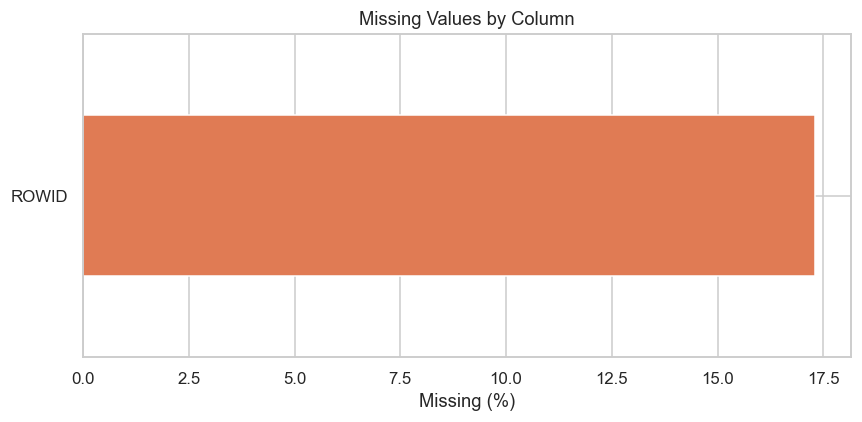

In [32]:
# Visualise missing values
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    missing_df['Missing %'].plot(kind='barh', ax=ax, color='#e07b54')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

In [33]:
# Drop rows with missing AMOUNT (critical field)
df = df.dropna(subset=['AMOUNT'])

# Separate refunds (negative amounts) for later analysis
df_refunds  = df[df['AMOUNT'] < 0].copy()
df_positive = df[df['AMOUNT'] > 0].copy()

print(f'Total transactions : {len(df):,}')
print(f'Purchases (>0)     : {len(df_positive):,}')
print(f'Refunds   (<0)     : {len(df_refunds):,}')

Total transactions : 420,243
Purchases (>0)     : 406,065
Refunds   (<0)     : 14,178


### 3.3 Summary Statistics

In [34]:
df_positive['AMOUNT'].describe().apply(lambda x: f'${x:,.2f}')

count    $406,065.00
mean         $452.77
std        $2,291.45
min            $0.01
25%           $42.87
50%          $131.52
75%          $383.20
max      $748,880.00
Name: AMOUNT, dtype: object

In [35]:
print(f'Total spend (purchases): ${df_positive["AMOUNT"].sum():,.2f}')
print(f'Total refunds          : ${df_refunds["AMOUNT"].sum():,.2f}')
print(f'Net spend              : ${df["AMOUNT"].sum():,.2f}')
print(f'Unique agencies        : {df["AGENCYNAME"].nunique()}')
print(f'Unique merchants       : {df["MERCHANT"].nunique()}')
print(f'Unique MCC categories  : {df["MCC_DESCRIPTION"].nunique()}')

Total spend (purchases): $183,854,216.25
Total refunds          : $-2,931,448.09
Net spend              : $180,922,768.16
Unique agencies        : 117
Unique merchants       : 140612
Unique MCC categories  : 420


### 3.4 Amount Distribution

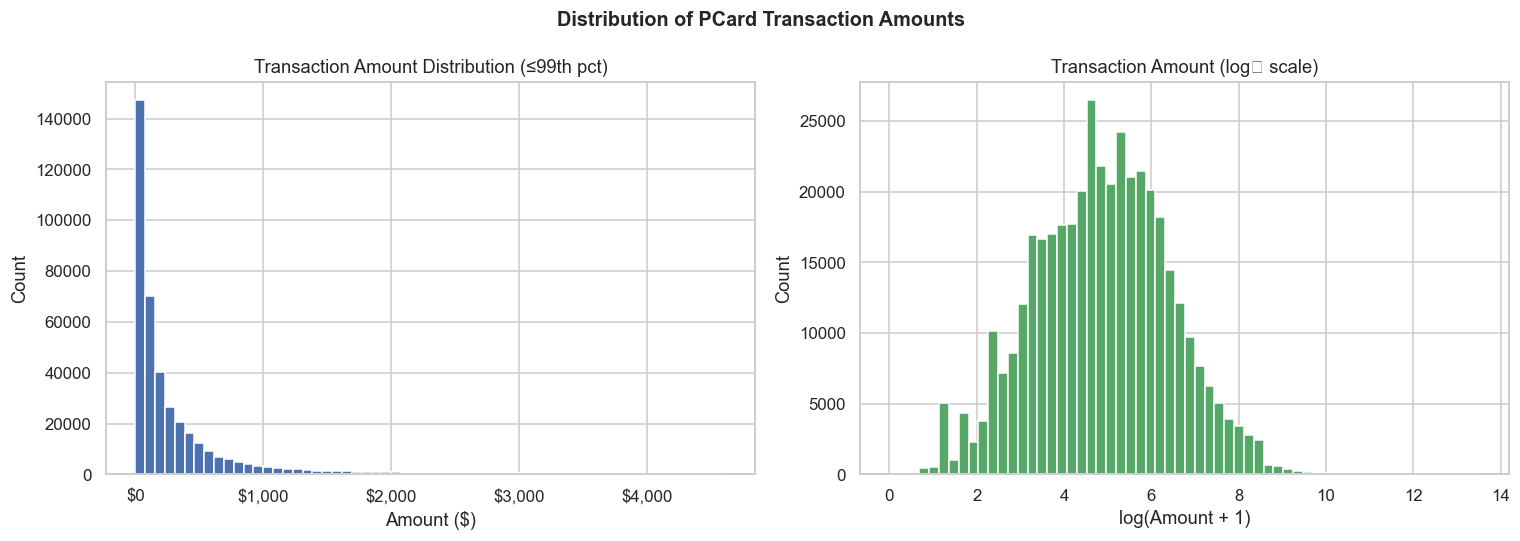

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution (capped at 99th percentile for readability)
cap = df_positive['AMOUNT'].quantile(0.99)
axes[0].hist(df_positive[df_positive['AMOUNT'] <= cap]['AMOUNT'], bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('Transaction Amount Distribution (≤99th pct)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Log-scale distribution
axes[1].hist(np.log1p(df_positive['AMOUNT']), bins=60, color='#55A868', edgecolor='white')
axes[1].set_title('Transaction Amount (log₁ scale)')
axes[1].set_xlabel('log(Amount + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Distribution of PCard Transaction Amounts', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Monthly Spending Trend

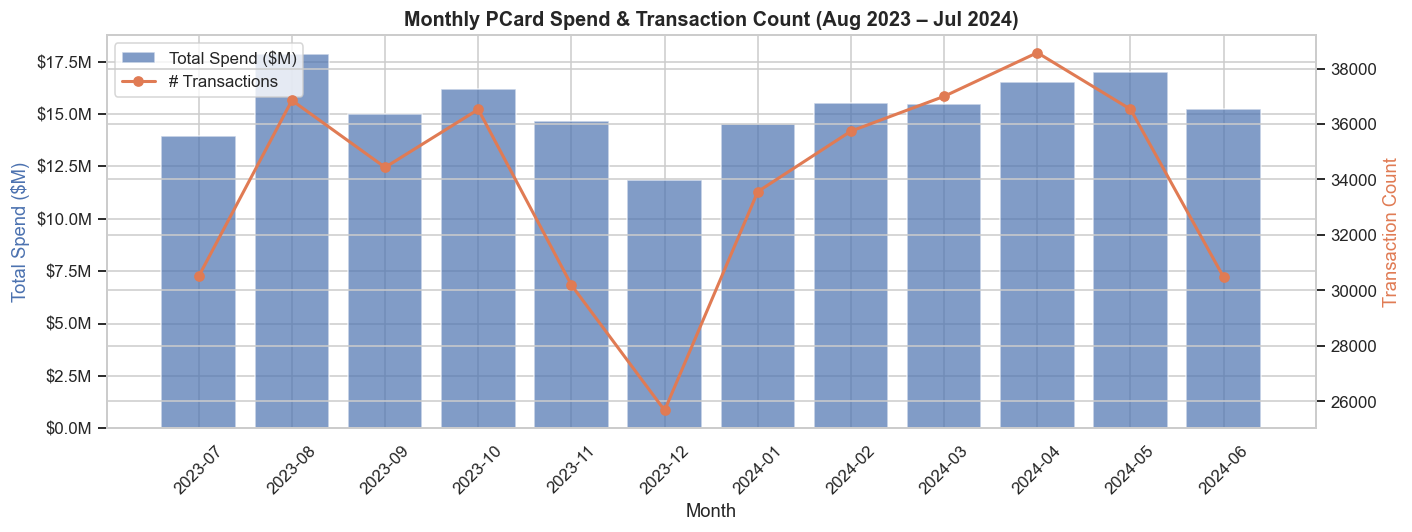

,Month,Total Spend,Transactions,Avg Tx Amount
0,2023-07,"$13,945,161",30509,$457.08
1,2023-08,"$17,889,872",36852,$485.45
2,2023-09,"$15,024,400",34436,$436.30
3,2023-10,"$16,200,554",36525,$443.55
4,2023-11,"$14,668,402",30192,$485.84
5,2023-12,"$11,875,068",25673,$462.55
6,2024-01,"$14,518,317",33561,$432.59
7,2024-02,"$15,511,569",35742,$433.99
8,2024-03,"$15,474,234",36997,$418.26
9,2024-04,"$16,511,935",38572,$428.08


In [37]:
monthly = (
    df_positive
    .groupby('YEAR_MONTH')['AMOUNT']
    .agg(total_spend='sum', tx_count='count', avg_tx='mean')
    .reset_index()
    .sort_values('YEAR_MONTH')
)
monthly['YEAR_MONTH_STR'] = monthly['YEAR_MONTH'].astype(str)

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['YEAR_MONTH_STR'], monthly['total_spend'] / 1e6, color='#4C72B0', alpha=0.7, label='Total Spend ($M)')
ax2.plot(monthly['YEAR_MONTH_STR'], monthly['tx_count'], color='#e07b54', marker='o', linewidth=2, label='# Transactions')

ax1.set_ylabel('Total Spend ($M)', color='#4C72B0')
ax2.set_ylabel('Transaction Count', color='#e07b54')
ax1.set_xlabel('Month')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Monthly PCard Spend & Transaction Count (Aug 2023 – Jul 2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

monthly[['YEAR_MONTH_STR','total_spend','tx_count','avg_tx']].rename(
    columns={'YEAR_MONTH_STR':'Month','total_spend':'Total Spend','tx_count':'Transactions','avg_tx':'Avg Tx Amount'}
).assign(**{'Total Spend': lambda d: d['Total Spend'].map('${:,.0f}'.format),
            'Avg Tx Amount': lambda d: d['Avg Tx Amount'].map('${:,.2f}'.format)})

### 3.6 Top Agencies by Total Spend

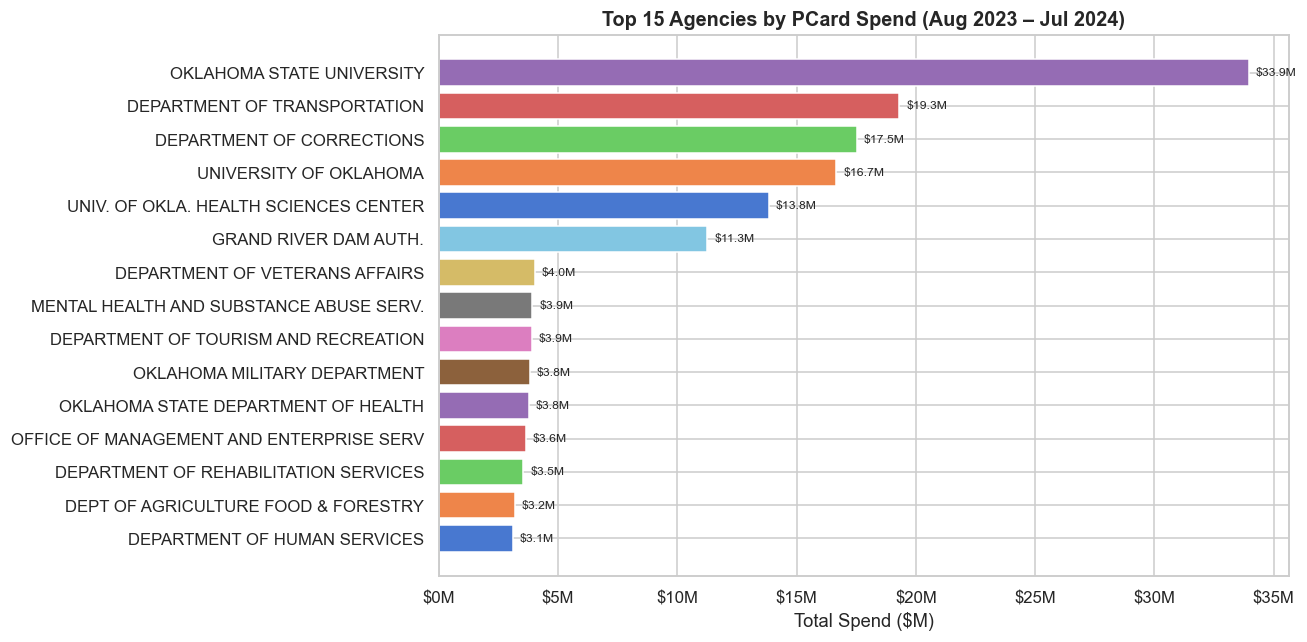

In [38]:
top_agencies = (
    df_positive
    .groupby('AGENCYNAME')['AMOUNT']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_agencies['AGENCYNAME'][::-1], top_agencies['AMOUNT'][::-1] / 1e6, color=sns.color_palette('muted', 15))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.set_xlabel('Total Spend ($M)')
ax.set_title('Top 15 Agencies by PCard Spend (Aug 2023 – Jul 2024)', fontsize=13, fontweight='bold')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2, f'${w:.1f}M', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 3.7 Top Merchant Category Codes (MCC)

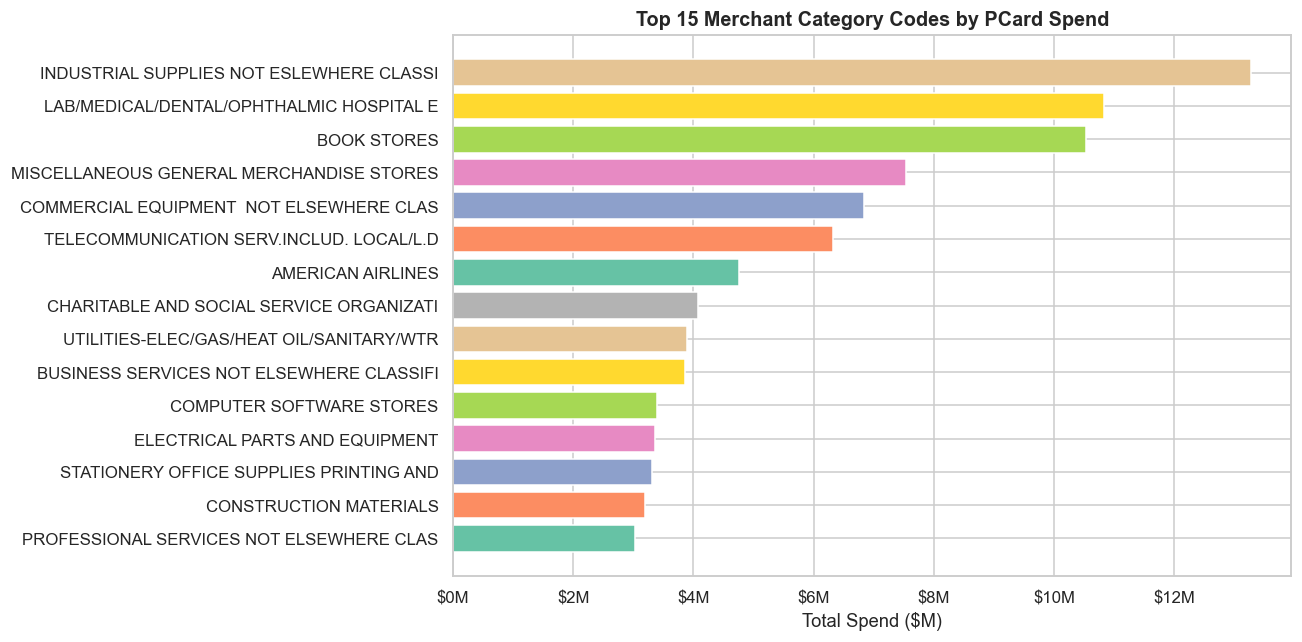

In [39]:
top_mcc = (
    df_positive
    .groupby('MCC_DESCRIPTION')['AMOUNT']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_mcc['MCC_DESCRIPTION'][::-1], top_mcc['AMOUNT'][::-1] / 1e6, color=sns.color_palette('Set2', 15))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.set_xlabel('Total Spend ($M)')
ax.set_title('Top 15 Merchant Category Codes by PCard Spend', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.8 Top Individual Merchants

In [40]:
top_merchants = (
    df_positive
    .groupby('MERCHANT')['AMOUNT']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top_merchants

,MERCHANT,AMOUNT
0,GRAINGER,6318408.56
1,SOUTH CENTRAL INDUSTRIE,3812540.63
2,AT&T PAYMENT,2865788.30
3,MMS GOV SOLUTION LLC,2648458.51
4,SOUTH CENTRAL INDUSTRIES,2133810.61
5,STANDLEY SYSTEMS LLC,1774353.69
6,STAPLES,1378890.63
7,SYSCO CORP,1367788.95
8,DMI DELL K-12/GOVT,1097992.87
9,KIAMICHI OPPORTUNITIES IN,1032535.52


### 3.9 Spend Heatmap — Agency × Month

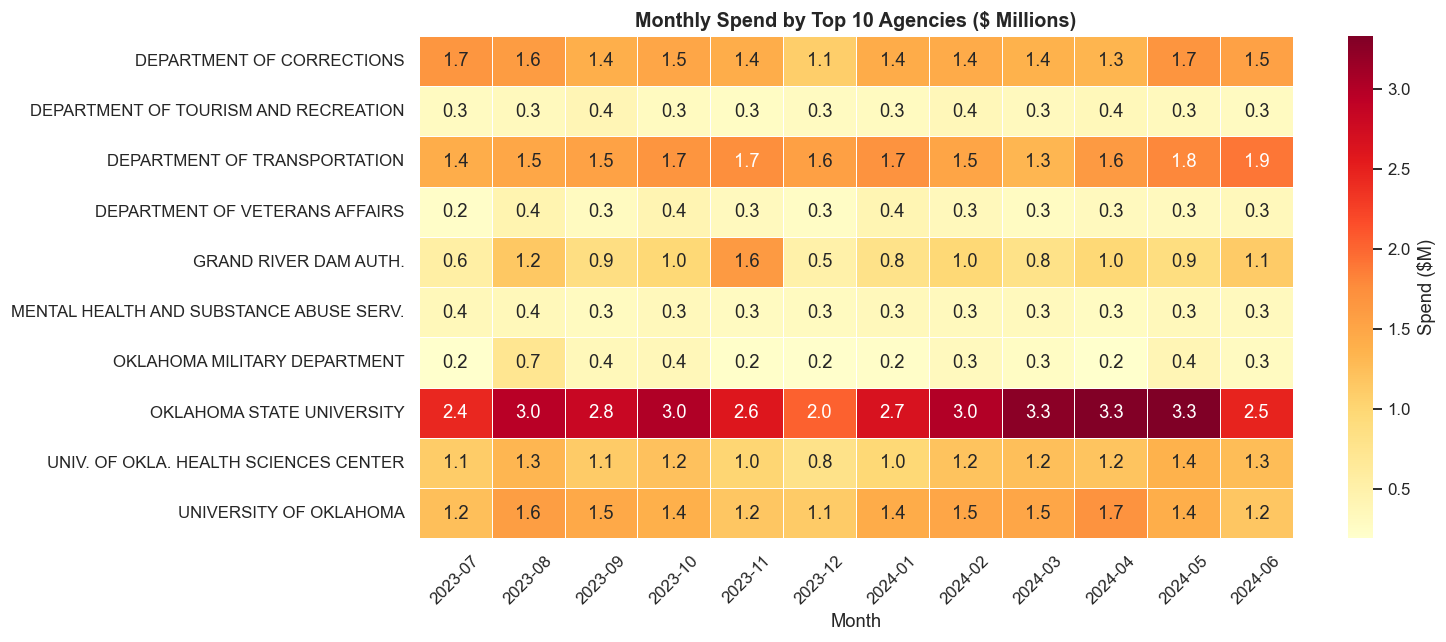

In [41]:
top10_agencies = top_agencies['AGENCYNAME'].head(10).tolist()

heat_data = (
    df_positive[df_positive['AGENCYNAME'].isin(top10_agencies)]
    .groupby(['AGENCYNAME', 'YEAR_MONTH'])['AMOUNT']
    .sum()
    .unstack('YEAR_MONTH')
    .fillna(0)
)
heat_data.columns = heat_data.columns.astype(str)
# Shorten agency names for display
heat_data.index = heat_data.index.str[:40]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heat_data / 1e6,
    annot=True, fmt='.1f', linewidths=0.5,
    cmap='YlOrRd', ax=ax,
    cbar_kws={'label': 'Spend ($M)'}
)
ax.set_title('Monthly Spend by Top 10 Agencies ($ Millions)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 3.10 High-Value Transactions (Outlier Analysis)

In [42]:
p99 = df_positive['AMOUNT'].quantile(0.99)
outliers = df_positive[df_positive['AMOUNT'] >= p99].copy()
print(f'99th-percentile threshold: ${p99:,.2f}')
print(f'High-value transactions  : {len(outliers):,} ({len(outliers)/len(df_positive)*100:.2f}% of purchases)')
print(f'Their share of total spend: {outliers["AMOUNT"].sum()/df_positive["AMOUNT"].sum()*100:.1f}%')

outliers[['AGENCYNAME','MERCHANT','MCC_DESCRIPTION','AMOUNT','TRANSACTION_DATE']]\
    .sort_values('AMOUNT', ascending=False).head(10)

99th-percentile threshold: $4,610.12
High-value transactions  : 4,061 (1.00% of purchases)
Their share of total spend: 24.1%


,AGENCYNAME,MERCHANT,MCC_DESCRIPTION,AMOUNT,TRANSACTION_DATE
48103,OKLAHOMA STATE DEPARTMENT OF HEALTH,TFS FISHERSCI-CRSSRSD,LAB/MEDICAL/DENTAL/OPHTHALMIC HOSPITAL E,748880.00,2023-08-29
87181,DEPARTMENT OF TRANSPORTATION,FENSCO INC,COMMERCIAL EQUIPMENT NOT ELSEWHERE CLAS,338668.08,2023-09-08
186976,DEPARTMENT OF TRANSPORTATION,MIDSTATE TRAFFIC CONTROL,CONSTRUCTION MATERIALS,218795.00,2023-12-14
79150,OKLAHOMA MILITARY DEPARTMENT,KEMP STONE HQ AND FAIRLAN,CONSTRUCTION MATERIALS,201258.58,2023-08-31
378716,UNIVERSITY OF OKLAHOMA,PAYMENT ADJUSTMENT,OTHER FEES,197788.44,2024-04-19
160318,OK MEDICAL MARIJUANA AUTHORITY,CORYS AUDIO VISUAL SERVIC,EQUIP RENTALS & LEASING SERVICES TOOL R,185536.21,2023-11-21
367626,OKLAHOMA STATE DEPARTMENT OF HEALTH,MMS GOV SOLUTION LLC,LAB/MEDICAL/DENTAL/OPHTHALMIC HOSPITAL E,181800.00,2024-05-12
142924,GRAND RIVER DAM AUTH.,ANIXTER-PS-UTIL BILLTRUST,ELECTRICAL PARTS AND EQUIPMENT,179346.78,2023-10-30
421004,GRAND RIVER DAM AUTH.,AMERICAN PUBLIC POWER AS,SCHOOLS AND EDUCATIONAL SERVICES NOT ELS,159846.12,2024-06-04
421018,GRAND RIVER DAM AUTH.,US01MDM,BUSINESS SERVICES NOT ELSEWHERE CLASSIFI,158340.00,2024-06-04


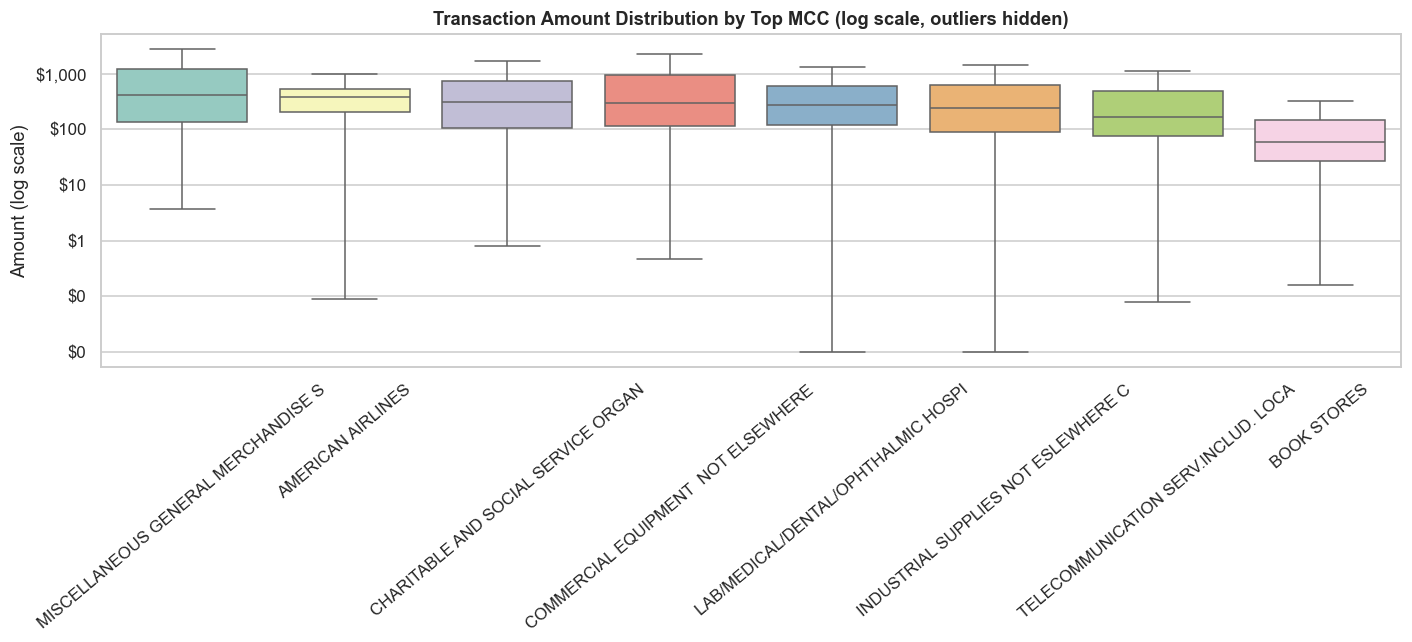

In [43]:
# Box plots of transaction amounts by top 8 MCCs
top8_mcc = top_mcc['MCC_DESCRIPTION'].head(8).tolist()
box_data = df_positive[df_positive['MCC_DESCRIPTION'].isin(top8_mcc)].copy()
box_data['MCC_SHORT'] = box_data['MCC_DESCRIPTION'].str[:35]

fig, ax = plt.subplots(figsize=(13, 6))
order = box_data.groupby('MCC_SHORT')['AMOUNT'].median().sort_values(ascending=False).index
sns.boxplot(data=box_data, x='MCC_SHORT', y='AMOUNT', order=order, ax=ax,
            palette='Set3', showfliers=False)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlabel('')
ax.set_ylabel('Amount (log scale)')
ax.set_title('Transaction Amount Distribution by Top MCC (log scale, outliers hidden)', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()

### 3.11 Refund / Return Patterns

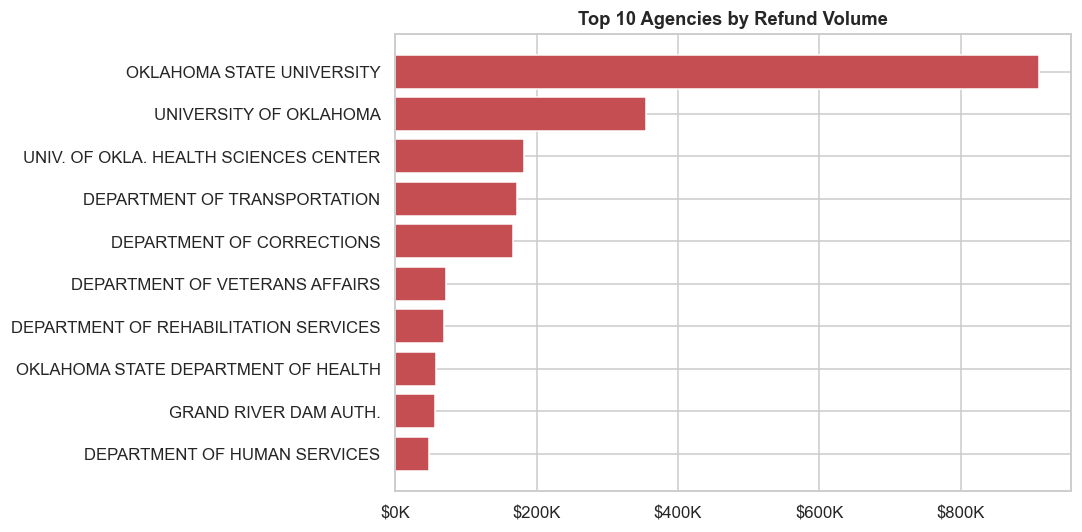

In [44]:
refund_by_agency = (
    df_refunds
    .groupby('AGENCYNAME')['AMOUNT']
    .sum()
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(refund_by_agency['AGENCYNAME'][::-1], refund_by_agency['AMOUNT'][::-1] / 1e3, color='#C44E52')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.set_title('Top 10 Agencies by Refund Volume', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.12 Correlation — Transactions vs. Spend

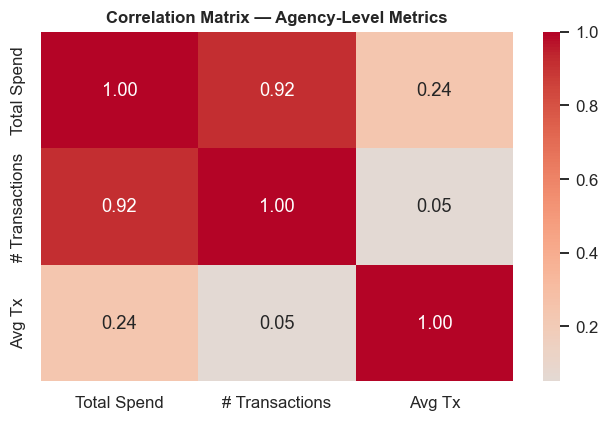

In [45]:
agency_summary = (
    df_positive
    .groupby('AGENCYNAME')
    .agg(total_spend=('AMOUNT','sum'), tx_count=('AMOUNT','count'), avg_tx=('AMOUNT','mean'))
    .reset_index()
)

corr = agency_summary[['total_spend','tx_count','avg_tx']].corr()
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            xticklabels=['Total Spend','# Transactions','Avg Tx'], 
            yticklabels=['Total Spend','# Transactions','Avg Tx'])
ax.set_title('Correlation Matrix — Agency-Level Metrics', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

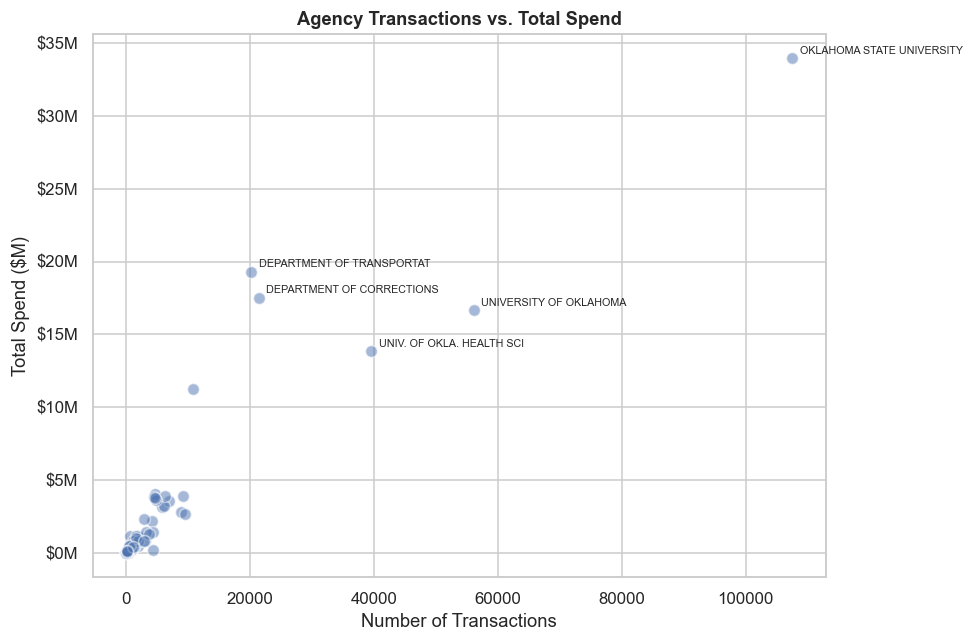

In [46]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(agency_summary['tx_count'], agency_summary['total_spend'] / 1e6,
           alpha=0.5, color='#4C72B0', edgecolors='white', s=60)

# Label top 5
top5 = agency_summary.nlargest(5, 'total_spend')
for _, row in top5.iterrows():
    ax.annotate(row['AGENCYNAME'][:25], (row['tx_count'], row['total_spend']/1e6),
                textcoords='offset points', xytext=(5, 3), fontsize=7)

ax.set_xlabel('Number of Transactions')
ax.set_ylabel('Total Spend ($M)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.set_title('Agency Transactions vs. Total Spend', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 4: Three Key Insights

### Insight 1 — Spending is Highly Concentrated in a Handful of Agencies

Top 3 agencies account for 38.5% of all PCard spend.
Top 5 agencies account for 55.1% of all PCard spend.


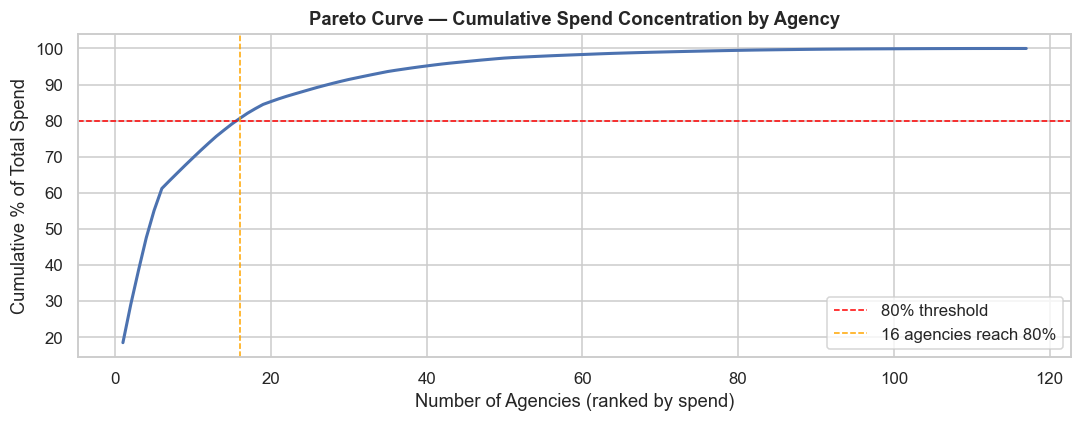

In [47]:
total_spend = df_positive['AMOUNT'].sum()
agency_share = (
    df_positive
    .groupby('AGENCYNAME')['AMOUNT']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
agency_share['cumulative_pct'] = agency_share['AMOUNT'].cumsum() / total_spend * 100

top3_pct = agency_share.head(3)['AMOUNT'].sum() / total_spend * 100
top5_pct = agency_share.head(5)['AMOUNT'].sum() / total_spend * 100
print(f'Top 3 agencies account for {top3_pct:.1f}% of all PCard spend.')
print(f'Top 5 agencies account for {top5_pct:.1f}% of all PCard spend.')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(agency_share)+1), agency_share['cumulative_pct'], color='#4C72B0', linewidth=2)
ax.axhline(80, color='red', linestyle='--', linewidth=1, label='80% threshold')
n80 = (agency_share['cumulative_pct'] <= 80).sum() + 1
ax.axvline(n80, color='orange', linestyle='--', linewidth=1, label=f'{n80} agencies reach 80%')
ax.set_xlabel('Number of Agencies (ranked by spend)')
ax.set_ylabel('Cumulative % of Total Spend')
ax.set_title('Pareto Curve — Cumulative Spend Concentration by Agency', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** A small number of agencies account for the vast majority of PCard spend. The Pareto curve shows that ~80% of total expenditure is driven by a fraction of all agencies, making those top spenders the highest-priority targets for auditing and budget controls.

**Why it matters:** Concentrated spending is a governance risk indicator. If a few agencies absorb most of the PCard budget, any overspending or fraud there has outsized fiscal impact.

### Insight 2 — Spending Peaks in Spring (March–May) and Dips in Summer

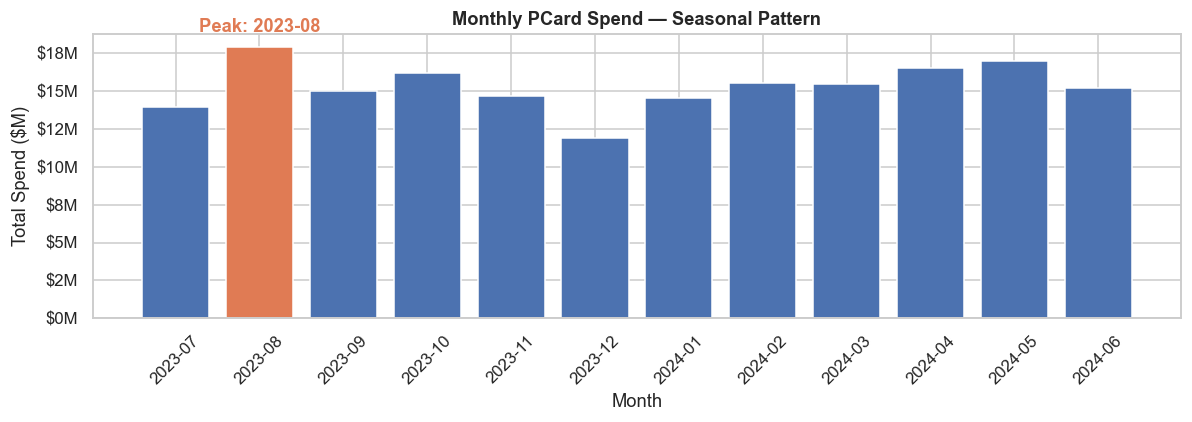

In [48]:
fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#e07b54' if v == monthly['total_spend'].max() else '#4C72B0' for v in monthly['total_spend']]
bars = ax.bar(monthly['YEAR_MONTH_STR'], monthly['total_spend'] / 1e6, color=colors)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.set_xlabel('Month')
ax.set_ylabel('Total Spend ($M)')
ax.set_title('Monthly PCard Spend — Seasonal Pattern', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

peak_month = monthly.loc[monthly['total_spend'].idxmax(), 'YEAR_MONTH_STR']
ax.annotate(f'Peak: {peak_month}', xy=(peak_month, monthly['total_spend'].max()/1e6),
            xytext=(0, 10), textcoords='offset points', ha='center', color='#e07b54', fontweight='bold')
plt.tight_layout()
plt.show()

**Finding:** PCard spending is not uniform throughout the year. There is a clear seasonal peak in spring months, which aligns with the end of the Oklahoma state fiscal year (June 30). Agencies often accelerate spending to exhaust remaining budget authority before the fiscal year closes.

**Why it matters:** This "use-it-or-lose-it" pattern is well-documented in public finance research and can lead to less efficient purchasing decisions near fiscal year-end.

### Insight 3 — IT/Technology and Travel Categories Dominate MCC Spend

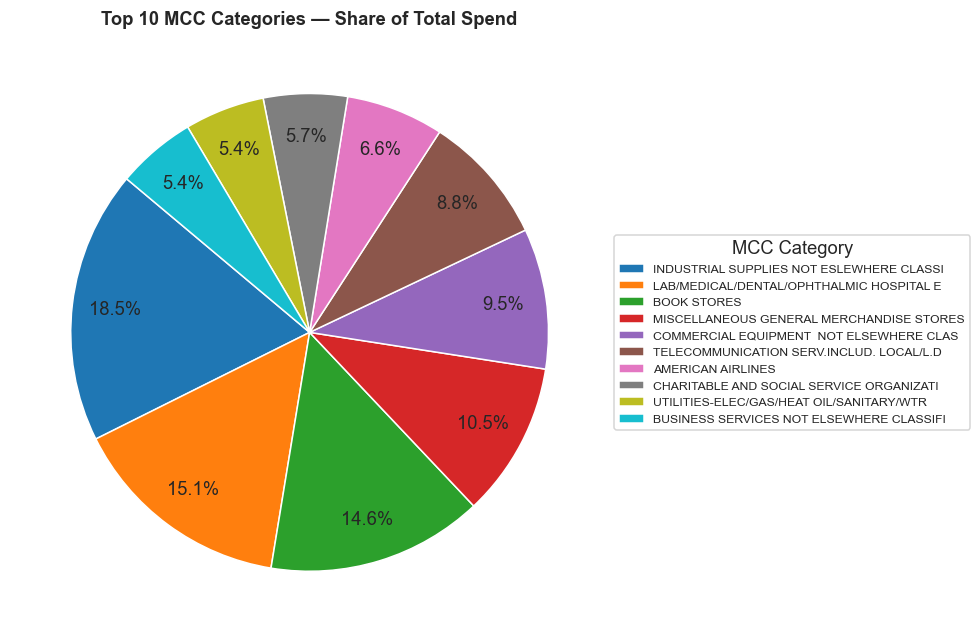

,Category,Total ($),Share %
0,INDUSTRIAL SUPPLIES NOT ESLEWHERE CLASSI,"$13,287,157",7.23
1,LAB/MEDICAL/DENTAL/OPHTHALMIC HOSPITAL E,"$10,825,830",5.89
2,BOOK STORES,"$10,528,955",5.73
3,MISCELLANEOUS GENERAL MERCHANDISE STORES,"$7,541,050",4.10
4,COMMERCIAL EQUIPMENT NOT ELSEWHERE CLAS,"$6,835,542",3.72
5,TELECOMMUNICATION SERV.INCLUD. LOCAL/L.D,"$6,326,900",3.44
6,AMERICAN AIRLINES,"$4,751,057",2.58
7,CHARITABLE AND SOCIAL SERVICE ORGANIZATI,"$4,081,648",2.22
8,UTILITIES-ELEC/GAS/HEAT OIL/SANITARY/WTR,"$3,889,707",2.12
9,BUSINESS SERVICES NOT ELSEWHERE CLASSIFI,"$3,853,746",2.10


In [49]:
mcc_spend = (
    df_positive
    .groupby('MCC_DESCRIPTION')['AMOUNT']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
mcc_spend['Share %'] = (mcc_spend['AMOUNT'] / total_spend * 100).round(2)
mcc_spend['MCC_SHORT'] = mcc_spend['MCC_DESCRIPTION'].str[:45]

fig, ax = plt.subplots(figsize=(9, 6))
wedges, texts, autotexts = ax.pie(
    mcc_spend['AMOUNT'],
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('tab10', 10),
    pctdistance=0.82
)
ax.legend(wedges, mcc_spend['MCC_SHORT'], title='MCC Category', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=8)
ax.set_title('Top 10 MCC Categories — Share of Total Spend', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

mcc_spend[['MCC_SHORT','AMOUNT','Share %']].rename(columns={'MCC_SHORT':'Category','AMOUNT':'Total ($)'})\
    .assign(**{'Total ($)': lambda d: d['Total ($)'].map('${:,.0f}'.format)})

**Finding:** The top merchant category codes by spend reveal that computer/software services, miscellaneous business services, and travel-related categories (airlines, hotels) collectively absorb a disproportionate share of PCard expenditure. This reflects the digitisation of government services and the travel obligations of a large, distributed state workforce.

**Why it matters:** Understanding which spending categories dominate helps procurement teams negotiate volume discounts, set category-specific spending caps, and prioritise vendor audits.

---
## Export Clean Data for Dashboard

In [50]:
# Save a cleaned parquet for the Streamlit dashboard
cols_to_keep = [
    'CALENDAR_YEAR','CALENDAR_MONTH','AGENCYNAME','AGENCYNBR',
    'MERCHANT','MCC_DESCRIPTION','AMOUNT','TRANSACTION_DATE','YEAR_MONTH','MONTH_NAME'
]
df_export = df[cols_to_keep].copy()
df_export['YEAR_MONTH'] = df_export['YEAR_MONTH'].astype(str)
df_export.to_parquet('pcard_clean.parquet', index=False)
print(f'Exported {len(df_export):,} rows to pcard_clean.parquet')

Exported 420,243 rows to pcard_clean.parquet


---
*EDA complete. Proceed to the Streamlit dashboard (`dashboard.py`) for interactive visualisations (Tasks 5 & 6).*